In [39]:
from admm2viz import ADMM2
from matplotlib import pyplot as plt
import numpy as np

### Instantiate the admm object (the run history is saved in .h5 files in hierarchical format)
#### data directory structure : root/{alpha_value}/{dim}.h5

In [37]:
admm2 = ADMM2(alpha=0.1, dim=64, base_dir="run_data_admm_gurobi")

### trial(i) represents trial index for the randomized IP solver in the loop
### for randomized solver, there is a single trial : trial(0)

### The full JSON tree can be viewed using :

In [ ]:
# admm.trial(0).describe_tree()

### Here is an example on how to access the data in series group 

In [4]:
admm2.trial(0).series.objective
#admm.trial(0).series.infeas

array([2.16239981, 1.83977216, 1.25603625, 1.21895587, 1.19987496,
       1.18576259, 1.17202912, 1.15391872, 1.13913206, 1.13273559,
       1.12659348, 1.11976124, 1.11562849, 1.11296668, 1.10990077,
       1.11376836, 1.10205397, 1.09768183, 1.0946459 , 1.0969347 ,
       1.08332699])

### Here is an example on how to access the data in iters group (5th control and state iterate)

In [6]:
control_5 = admm2.trial(0).iters.control_2[10]
control_5_cont = admm2.trial(0).iters.control_1[10]
state_5 = admm2.trial(0).iters.state[15]

###  For randomized solver we store the median and best control, objective etc separately

In [5]:
admm.objective   #median
admm.objective_best #best

## Same for control
admm.control_1   #median
admm.control_1_best #best

array([1.        , 1.00000001, 1.        , ..., 1.00000001, 1.        ,
       1.00000001])

### Plot the best and median control across runs

Please enter a valid value for 'which' \in {1, 2}


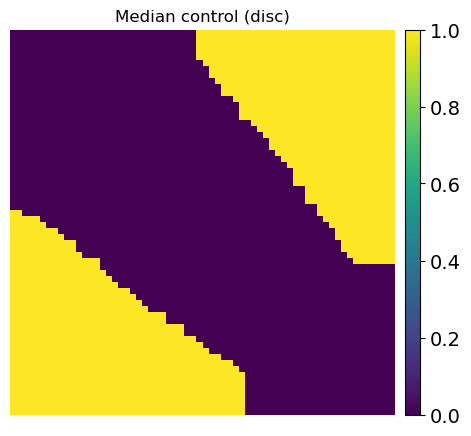

In [38]:
admm2.plot_control(disc=True) #median

### To plot a specific iterate, you can pass it as an argument

In [ ]:
fig,ax = plt.subplots(figsize=(6,6), nrows=1, ncols=2)

c5 = admm.trial(0).iters.control[5]
s5 = admm.trial(0).iters.state[5]
admm.plot_control(c5, ax=ax[0])
admm.plot_state(s5, ax=ax[1])

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/dolfin/common/plotting.py:152: UserWarning: The following kwargs were not used by contour: 'edgecolor'
  return ax.tricontourf(mesh2triang(mesh), C, levels, **kwargs)


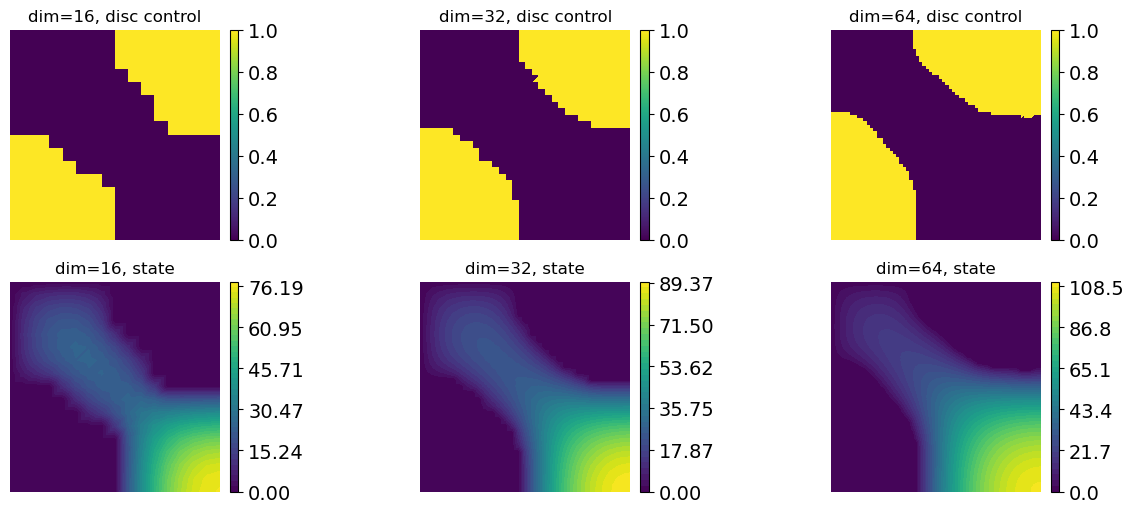

In [44]:
mesh_list = [16,32,64]
fig,ax = plt.subplots(figsize=(15,6), nrows=2, ncols=3)
for i, mesh in enumerate(mesh_list):
    admmcolin = ADMM2(alpha=1.0, dim=mesh, base_dir="run_data_admm_gurobi")
    c = admmcolin.trial(0).iters.control_disc[-1]
    s = admmcolin.trial(0).iters.state[-1]
    admmcolin.plot_control(c, ax=ax[0][i], show=False, title=f"dim={mesh}, disc control")
    admmcolin.plot_state(s, ax=ax[1][i], show=False, title=f"dim={mesh}, state")